# R2：隐藏层与 ReLU

目标：通过一个无法被直线正确分开的数据集，理解隐藏层与 ReLU 为什么能让神经网络学习非线性关系。

## 为什么线性模型不够

本节数据的正类位于左下和右上，负类位于左上和右下。这类似 XOR：无法用一条直线把两类完全分开。

- 线性模型：`Linear(2, 1)`，只能形成直线边界。
- 多层网络：`Linear(2, 8) → ReLU → Linear(8, 1)`，可形成更复杂的分段边界。

若只叠加多个 Linear 而没有激活函数，它们仍等价于一个线性变换；ReLU 才引入非线性。

In [1]:
import copy

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

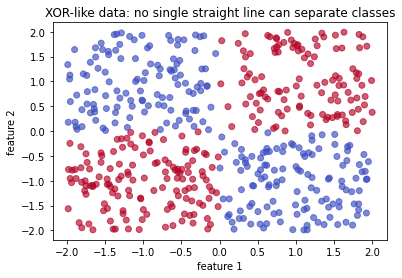

In [2]:
# 在 [-2, 2] 平面随机取点：横纵坐标同号为正类，不同号为负类。
X_all = torch.rand(500, 2) * 4 - 2
y_all = ((X_all[:, 0] * X_all[:, 1]) > 0).float().reshape(-1, 1)

indices = torch.randperm(len(X_all))
train_indices, val_indices = indices[:400], indices[400:]
X_train, y_train = X_all[train_indices], y_all[train_indices]
X_val, y_val = X_all[val_indices], y_all[val_indices]

plt.scatter(X_all[:, 0], X_all[:, 1], c=y_all.squeeze(), cmap='coolwarm', alpha=0.65)
plt.title('XOR-like data: no single straight line can separate classes')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()

In [3]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)
loss_function = nn.BCEWithLogitsLoss()

def fit_and_evaluate(model, epochs=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
    best_val_loss = float('inf')
    best_state = None

    for _ in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = loss_function(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = loss_function(val_logits, y_val).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(model(X_val))
        predictions = (probabilities >= 0.5).float()
        accuracy = (predictions == y_val).float().mean().item()

    return accuracy, best_val_loss

In [4]:
# 基线：只有一层线性变换，不能解决 XOR 结构。
linear_model = nn.Linear(2, 1)
linear_accuracy, linear_val_loss = fit_and_evaluate(linear_model)

# MLP：先从 2 个输入特征提取 8 个隐藏特征，再经 ReLU 非线性激活，最后输出一个 logit。
mlp_model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)
mlp_accuracy, mlp_val_loss = fit_and_evaluate(mlp_model)

print(f'linear model validation accuracy: {linear_accuracy:.3f}, BCE: {linear_val_loss:.3f}')
print(f'MLP validation accuracy:          {mlp_accuracy:.3f}, BCE: {mlp_val_loss:.3f}')

linear model validation accuracy: 0.550, BCE: 0.688
MLP validation accuracy:          0.980, BCE: 0.055


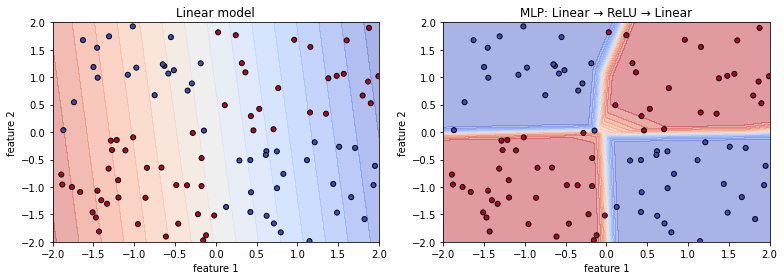

In [5]:
def draw_decision_boundary(model, title):
    grid_x, grid_y = torch.meshgrid(
        torch.linspace(-2, 2, 150),
        torch.linspace(-2, 2, 150),
        indexing='ij',
    )
    grid = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=1)

    model.eval()
    with torch.no_grad():
        grid_probability = torch.sigmoid(model(grid)).reshape(150, 150)

    plt.contourf(grid_x.numpy(), grid_y.numpy(), grid_probability.numpy(), levels=20, cmap='coolwarm', alpha=0.45)
    plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val.squeeze(), cmap='coolwarm', edgecolor='black', s=25)
    plt.title(title)
    plt.xlabel('feature 1')
    plt.ylabel('feature 2')

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
draw_decision_boundary(linear_model, 'Linear model')
plt.subplot(1, 2, 2)
draw_decision_boundary(mlp_model, 'MLP: Linear → ReLU → Linear')
plt.tight_layout()
plt.show()

## 本节结论

隐藏层不是为了“层数更多”而存在，而是用来构造更有表达能力的特征；ReLU 提供非线性，使神经网络可以拟合直线无法处理的关系。下一节学习 Dropout 和 weight decay 如何控制网络复杂度、防止过拟合。